In [79]:
import joblib
import os
import pandas as pd
import numpy as np

from sklearn.metrics import recall_score, classification_report, confusion_matrix, roc_auc_score

In [80]:
X_test = pd.read_csv('./dataset/ciclos_test/test_filenames.csv')['cycle_wav_file']

In [81]:
y_test = pd.read_csv('./dataset/ciclos_test/test_filenames.csv')['label']

In [82]:
parent_dir = './dataset/ciclos'

X_test = X_test.apply(lambda x: os.path.join(parent_dir, x))
X_test

0       ./dataset/ciclos\130_2b3_Tc_mc_AKGC417L_cycle8...
1       ./dataset/ciclos\178_1b6_Ll_mc_AKGC417L_cycle8...
2       ./dataset/ciclos\163_8b3_Lr_mc_AKGC417L_cycle6...
3       ./dataset/ciclos\218_1b1_Pl_sc_Meditron_cycle1...
4       ./dataset/ciclos\117_1b3_Tc_mc_LittC2SE_cycle2...
                              ...                        
1351    ./dataset/ciclos\178_1b2_Ar_mc_AKGC417L_cycle4...
1352    ./dataset/ciclos\111_1b2_Tc_sc_Meditron_cycle8...
1353    ./dataset/ciclos\107_3p2_Pl_mc_AKGC417L_cycle5...
1354    ./dataset/ciclos\213_1p3_Pr_mc_AKGC417L_cycle6...
1355    ./dataset/ciclos\211_1p3_Ar_mc_AKGC417L_cycle6...
Name: cycle_wav_file, Length: 1356, dtype: object

In [83]:
modelo = joblib.load('./modelos/melspec_bp100_4000_wd_rf.pkl')

In [84]:
y_test_proba_pred = modelo.predict_proba(X_test)[:, 1]
umbral = 0.4
y_pred_custom = (y_test_proba_pred >= umbral).astype(int)

In [86]:
y_test_pred = modelo.predict(X_test)
print(classification_report(y_test, y_test_pred, target_names=['normal', 'anormal']))
print('ROC AUC:', roc_auc_score(y_test, y_test_proba_pred))

              precision    recall  f1-score   support

      normal       0.67      0.72      0.69       710
     anormal       0.66      0.62      0.64       646

    accuracy                           0.67      1356
   macro avg       0.67      0.67      0.67      1356
weighted avg       0.67      0.67      0.67      1356

ROC AUC: 0.7471983604412855


In [ ]:
print(classification_report(y_test, y_pred_custom, target_names=['normal', 'anormal']))

              precision    recall  f1-score   support

      normal       0.77      0.52      0.62       710
     anormal       0.61      0.83      0.70       646

    accuracy                           0.66      1356
   macro avg       0.69      0.67      0.66      1356
weighted avg       0.69      0.66      0.66      1356

ROC AUC: 0.7471983604412855


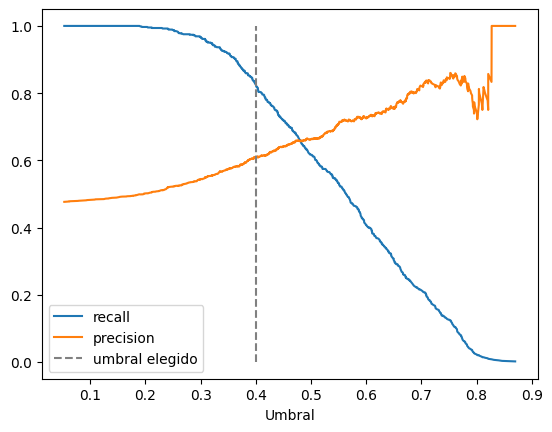

In [87]:
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_test, y_test_proba_pred)

# Graficar para elegir
import matplotlib.pyplot as plt
plt.plot(thr, rec[:-1], label='recall')
plt.plot(thr, prec[:-1], label='precision')
plt.xlabel('Umbral')
plt.vlines(umbral, 0, 1, colors='gray', linestyles='dashed', label='umbral elegido')
plt.legend()
plt.show()

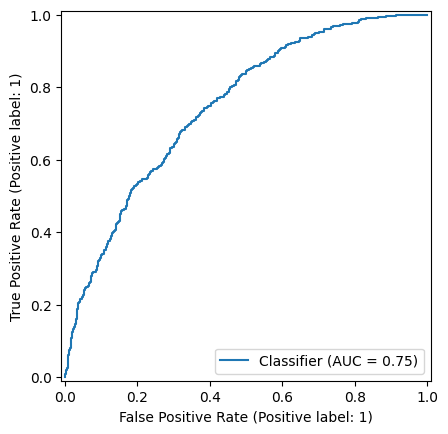

In [88]:
# plot roc curve
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_test_proba_pred)
plt.show()